# Generative Kuramoto: FM vs CNF (Exact & Hutchinson) with Diffrax

This notebook implements a generative model based on Kuramoto Oscillator dynamics.

**New Features:**
- **Type Hinting:** All functions and modules are strictly typed.
- **CNF Trace Estimators:** 
    - **Exact:** Uses `jax.jacrev` to compute the full Jacobian diagonal.
    - **Hutchinson:** Uses `jax.jvp` with random Rademacher noise to estimate the trace.
- **Time-Varying Experiments:** Explicitly compares static vs dynamic coupling weights.


In [11]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import numpy as np
import diffrax
from jaxtyping import Array, Float, PRNGKeyArray
import matplotlib.pyplot as plt
from typing import Optional, Literal, Tuple, Callable, Union, Any

# Ensure double precision
jax.config.update("jax_enable_x64", True)

### 1. Data & Geometry Utilities

In [12]:
def make_xor(n_samples: int, noise: float = 0.05) -> Float[np.ndarray, "n_samples 2"]:
    centers = np.array([[0.0, 1.0], [0.0, -1.0], [-1.0, 0.0], [1.0, 0.0]])
    labels = np.random.randint(0, 4, size=n_samples)
    data = centers[labels] + np.random.normal(scale=noise, size=(n_samples, 2))
    return data * np.pi


def wrap_to_pi(x: Array) -> Array:
    return (x + jnp.pi) % (2 * jnp.pi) - jnp.pi


def geodesic_diff(x1: Array, x0: Array) -> Array:
    return wrap_to_pi(x1 - x0)


def geodesic_interp(x0: Array, x1: Array, t: Array) -> Array:
    vel = geodesic_diff(x1, x0)
    return wrap_to_pi(x0 + t * vel)

### 2. Physics Engine (Kuramoto)

In [13]:
class KuramotoSystem(eqx.Module):
    coupling_K: Optional[Array] = None
    injection_A: Optional[Array] = None
    k_net: Optional[eqx.nn.MLP] = None
    a_net: Optional[eqx.nn.MLP] = None

    dim: int
    time_varying: bool

    def __init__(self, dim: int, key: PRNGKeyArray, time_varying: bool = False):
        self.dim = dim
        self.time_varying = time_varying
        k1, k2 = jax.random.split(key)

        if not time_varying:
            # Static: Learnable parameters directly
            self.coupling_K = jax.random.normal(k1, (dim, dim)) * 0.01
            self.injection_A = jax.random.normal(k2, (dim,)) * 0.01
        else:
            # Dynamic: MLPs map t -> weights
            self.k_net = eqx.nn.MLP(1, dim * dim, 64, 2, jax.nn.tanh, key=k1)
            self.a_net = eqx.nn.MLP(1, dim, 64, 2, jax.nn.tanh, key=k2)

    def _get_weights(self, t: Array) -> Tuple[Array, Array]:
        if self.time_varying and self.k_net is not None and self.a_net is not None:
            t_arr = jnp.atleast_1d(t)
            K = self.k_net(t_arr).reshape(self.dim, self.dim)
            A = self.a_net(t_arr)
            return K, A
        elif self.coupling_K is not None and self.injection_A is not None:
            return self.coupling_K, self.injection_A
        else:
            raise ValueError("Model initialized incorrectly.")

    def __call__(self, t: Array, x: Array, args: Any = None) -> Array:
        K, A = self._get_weights(t)
        diff_matrix = x[None, :] - x[:, None]
        interactions = jnp.sum(K * jnp.sin(diff_matrix), axis=1)
        injection = A * jnp.sin(2 * x)
        return interactions + injection

### 3. Joint Model & Latent Strategies

In [14]:
class LatentTargetEncoder(eqx.Module):
    net: Optional[eqx.nn.MLP]

    def __init__(self, vis_dim: int, lat_dim: int, key: PRNGKeyArray):
        if lat_dim > 0:
            self.net = eqx.nn.MLP(vis_dim, lat_dim, 64, 3, jax.nn.elu, key=key)
        else:
            self.net = None

    def __call__(self, x_vis: Array) -> Array:
        if self.net is None:
            return jnp.zeros((0,))
        return wrap_to_pi(self.net(x_vis))


class JointModel(eqx.Module):
    physics: KuramotoSystem
    encoder: LatentTargetEncoder
    vis_dim: int
    lat_dim: int
    latent_strategy: Literal["learned", "random"]

    def __init__(
        self,
        vis_dim: int,
        lat_dim: int,
        key: PRNGKeyArray,
        time_varying: bool = False,
        latent_strategy: Literal["learned", "random"] = "learned",
    ):
        k_phys, k_enc = jax.random.split(key)
        self.vis_dim = vis_dim
        self.lat_dim = lat_dim
        self.latent_strategy = latent_strategy

        self.physics = KuramotoSystem(vis_dim + lat_dim, k_phys, time_varying)
        self.encoder = LatentTargetEncoder(vis_dim, lat_dim, k_enc)

### 4. Trace Estimators & Loss Functions

In [26]:
def get_target_latents(model: JointModel, x_vis_1: Array, key: PRNGKeyArray) -> Array:
    if model.lat_dim == 0:
        return jnp.zeros((x_vis_1.shape[0], 0))

    if model.latent_strategy == "learned":
        return jax.vmap(model.encoder)(x_vis_1)
    else:
        # Random Strategy: Target is standard noise (wrapped)
        raw_noise = jax.random.normal(key, (x_vis_1.shape[0], model.lat_dim))
        return wrap_to_pi(raw_noise)


# --- Trace Helper Functions ---
def exact_div(f: Callable[[Array, Array, Any], Array], t: Array, x: Array) -> Array:
    """Computes exact divergence using jax.jacrev."""
    jac = jax.jacrev(lambda _x: f(t, _x, None))(x)
    return jnp.trace(jac)


def hutchinson_div(
    f: Callable[[Array, Array, Any], Array], t: Array, x: Array, key: PRNGKeyArray
) -> Array:
    """Computes Hutchinson trace estimate using jax.jvp and Rademacher noise."""
    epsilon = jax.random.rademacher(key, x.shape).astype(x.dtype)
    # JVP: forward mode derivative (Jacobian * vector)
    _, jvp_val = jax.jvp(lambda _x: f(t, _x, None), (x,), (epsilon,))
    return jnp.dot(epsilon, jvp_val)


# --- Loss Functions ---
def loss_fm(
    model: JointModel, x_vis_1: Array, x_0_full: Array, t: Array, key: PRNGKeyArray
) -> Tuple[Array, Tuple[Array, Array]]:

    target_latents = get_target_latents(model, x_vis_1, key)
    x_1_full = jnp.concatenate([x_vis_1, target_latents], axis=1)

    # Geodesic Interpolation
    u_t = geodesic_diff(x_1_full, x_0_full)
    x_t = geodesic_interp(x_0_full, x_1_full, t)

    # Vector Field Regression
    v_pred = jax.vmap(model.physics)(t, x_t)
    diff_sq = (v_pred - u_t) ** 2

    vis_loss = jnp.mean(diff_sq[:, : model.vis_dim])
    lat_loss = jnp.mean(diff_sq[:, model.vis_dim :]) if model.lat_dim > 0 else 0.0

    return vis_loss + lat_loss, (vis_loss, lat_loss)


def loss_cnf(
    model: JointModel,
    x_vis_1: Array,
    x_0_full: Array,
    t: Array,
    key: PRNGKeyArray,
    trace_method: Literal["exact", "hutchinson"] = "exact",
) -> Tuple[Array, Tuple[Array, Array]]:

    target_latents = get_target_latents(model, x_vis_1, key)
    x_1 = jnp.concatenate([x_vis_1, target_latents], axis=1)

    # Define Augmented Dynamics for Diffrax
    def aug_dynamics(
        t: Float, y: Tuple[Array, Array], args: Any
    ) -> Tuple[Array, Array]:
        x, _ = y
        dx = model.physics(t, x)

        # Compute Div based on method
        if trace_method == "exact":
            div = exact_div(model.physics, t, x)
        else:
            # We need a new key for hutchinson noise at every step.
            # Diffrax doesn't natively pass PRNGKey in dynamics state easily without custom solver modifications.
            # For simplicity in this demo, we fold a random seed into the state or use a simple hack.
            # Better approach: use `diffrax.VirtualBrownianTree` or similar if noise needs to be consistent,
            # but for Hutchinson, independent noise per step is preferred.
            # We will generate a "pseudo-random" key based on t and x for demo determinism/statelessness,
            # or simply use a global key if acceptable (not pure).
            # PURE JAX approach: fold key into state or args.
            # Here we use 'jax.random.fold_in' with 't' to get a changing key.
            h_key = jax.random.fold_in(key, jnp.array(t * 1000, dtype=jnp.int32))
            div = hutchinson_div(model.physics, t, x, h_key)

        return (dx, -div)  # dlogp/dt = -div

    def integrate_single(x_start: Array) -> Tuple[Array, Array]:
        term = diffrax.ODETerm(aug_dynamics)
        solver = diffrax.Tsit5()
        stepsize_controller = diffrax.PIDController(rtol=1e-3, atol=1e-3)

        # Integrate Backward: 1.0 -> 0.0
        sol = diffrax.diffeqsolve(
            term,
            solver,
            t0=1.0,
            t1=0.0,
            dt0=-0.05,
            y0=(x_start, 0.0),
            stepsize_controller=stepsize_controller,
        )
        return sol.ys[0][-1], sol.ys[1][-1]

    x_0_pred, delta_logp = jax.vmap(integrate_single)(x_1)

    loss = jnp.mean(delta_logp)
    return loss, (loss, 0.0)

### 5. Training & Generation Logic

In [27]:
@eqx.filter_jit
def train_step(
    model: JointModel,
    optim: optax.GradientTransformation,
    opt_state: optax.OptState,
    x_vis_batch: Array,
    key: PRNGKeyArray,
    method: Literal["fm", "cnf_exact", "cnf_hutchinson"],
) -> Tuple[Float, Tuple[Float, Float], JointModel, optax.OptState]:

    k1, k2, k3 = jax.random.split(key, 3)

    total_dim = model.vis_dim + model.lat_dim
    # x_0 for FM or Random seeds
    x_0 = jax.random.uniform(
        k1, (len(x_vis_batch), total_dim), minval=-jnp.pi, maxval=jnp.pi
    )
    # t for FM
    t = jax.random.uniform(k2, (len(x_vis_batch), 1))

    def loss_wrapper(m: JointModel) -> Tuple[Array, Tuple[Array, Array]]:
        if method == "fm":
            return loss_fm(m, x_vis_batch, x_0, t, k3)
        elif method == "cnf_exact":
            return loss_cnf(m, x_vis_batch, x_0, t, k3, trace_method="exact")
        elif method == "cnf_hutchinson":
            return loss_cnf(m, x_vis_batch, x_0, t, k3, trace_method="hutchinson")
        else:
            # Fallback
            return loss_fm(m, x_vis_batch, x_0, t, k3)

    (loss, aux), grads = eqx.filter_value_and_grad(loss_wrapper, has_aux=True)(model)

    updates, opt_state = optim.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)

    return loss, aux, model, opt_state


def sample_gen(model: JointModel, n_samples: int) -> Array:
    total_dim = model.vis_dim + model.lat_dim
    x_init = jax.random.uniform(
        jax.random.PRNGKey(99), (n_samples, total_dim), minval=-jnp.pi, maxval=jnp.pi
    )

    def dynamics(t: Float, x: Array, args: Any) -> Array:
        return model.physics(t, x)

    def solve_single(x0: Array) -> Array:
        term = diffrax.ODETerm(dynamics)
        solver = diffrax.Tsit5()
        sol = diffrax.diffeqsolve(
            term,
            solver,
            t0=0.0,
            t1=1.0,
            dt0=0.05,
            y0=x0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-3),
        )
        return sol.ys[-1]

    return jax.vmap(solve_single)(x_init)

### 6. Experiments

Run: CNF_EXACT | learned | Lat=0 | TV=False
  Step 0 Loss: -0.0111
  Step 50 Loss: -0.2972
  Step 100 Loss: -0.5793
  Step 150 Loss: -0.8471
Run: CNF_EXACT | learned | Lat=4 | TV=False
  Step 0 Loss: 0.0377
  Step 50 Loss: -1.1746
  Step 100 Loss: -2.5429
  Step 150 Loss: -3.8722
Run: CNF_EXACT | learned | Lat=0 | TV=True
  Step 0 Loss: 1.2740
  Step 50 Loss: -3.0029
  Step 100 Loss: -3.6805
  Step 150 Loss: -3.4962
Run: CNF_EXACT | learned | Lat=4 | TV=True
  Step 0 Loss: 1.9510
  Step 50 Loss: -15.9553
  Step 100 Loss: -16.9166
  Step 150 Loss: -16.1772


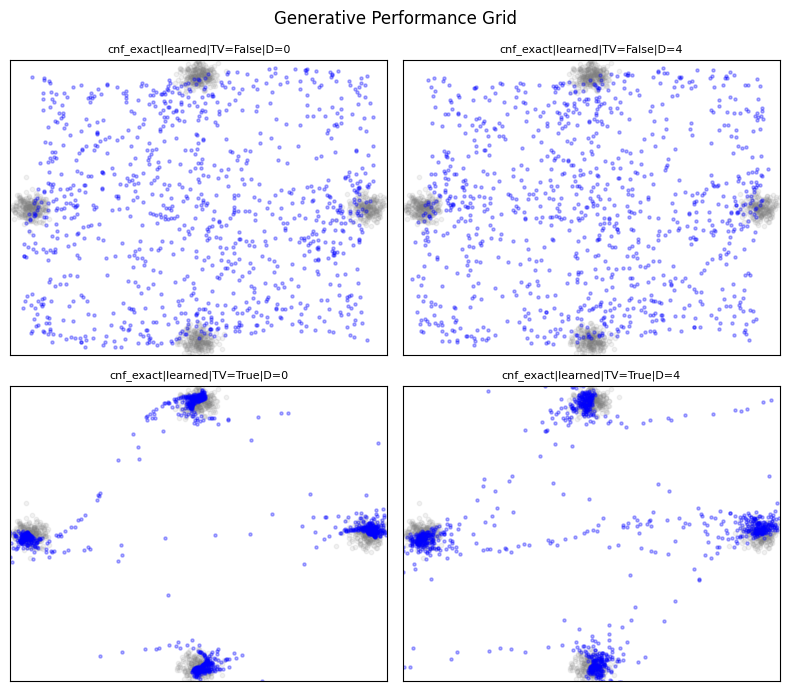

In [28]:
def run_experiment(
    method: Literal["fm", "cnf_exact"],
    latent_strategy: Literal["learned", "random"],
    lat_dim: int,
    time_varying: bool,
    steps: int = 1000,
    batch_size: int = 64,
) -> Tuple[list, list, Array]:

    print(
        f"Run: {method.upper()} | {latent_strategy} | Lat={lat_dim} | TV={time_varying}"
    )

    key = jax.random.PRNGKey(42)
    model = JointModel(2, lat_dim, key, time_varying, latent_strategy)
    optim = optax.adam(1e-3)
    opt_state = optim.init(eqx.filter(model, eqx.is_array))

    data = jnp.array(make_xor(5000))
    losses, vis_losses = [], []

    for i in range(steps):
        key, k_batch = jax.random.split(key)
        idx = jax.random.randint(k_batch, (batch_size,), 0, len(data))
        batch = data[idx]

        loss, (l_vis, _), model, opt_state = train_step(
            model, optim, opt_state, batch, key, method
        )
        losses.append(loss)
        vis_losses.append(l_vis)

        if i % 50 == 0:
            print(f"  Step {i} Loss: {loss:.4f}")

    gen_samples = sample_gen(model, 1000)
    return losses, vis_losses, gen_samples[:, :2]


# --- CONFIGURATION ---
methods = ["cnf_exact"]
strategies = ["learned"]
dims = [0, 4]
time_vary_opts = [False, True]

rows = len(methods) * len(strategies) * len(time_vary_opts)
cols = len(dims)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
fig.suptitle("Generative Performance Grid")

gt_data = make_xor(1000)
results_log = []

row_idx = 0
for m in methods:
    for s in strategies:
        for tv in time_vary_opts:
            for j, d in enumerate(dims):
                # If Dim=0, Strategy is irrelevant, but we keep loop simple
                # We skip 'Random' for Dim=0 to avoid duplicate plots of same model
                if d == 0 and s == "random":
                    # Just placeholder blank or copy
                    axes[row_idx, j].axis("off")
                    continue

                t_loss, v_loss, samples = run_experiment(m, s, d, tv, steps=200)

                ax = axes[row_idx, j]
                ax.scatter(gt_data[:, 0], gt_data[:, 1], c="gray", alpha=0.1, s=10)
                ax.scatter(samples[:, 0], samples[:, 1], c="blue", alpha=0.3, s=5)

                label = f"{m}|{s}|TV={tv}|D={d}"
                ax.set_title(label, fontsize=8)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_xlim(-3.5, 3.5)
                ax.set_ylim(-3.5, 3.5)

                results_log.append({"label": label, "loss": t_loss})
            row_idx += 1

plt.tight_layout()
plt.show()

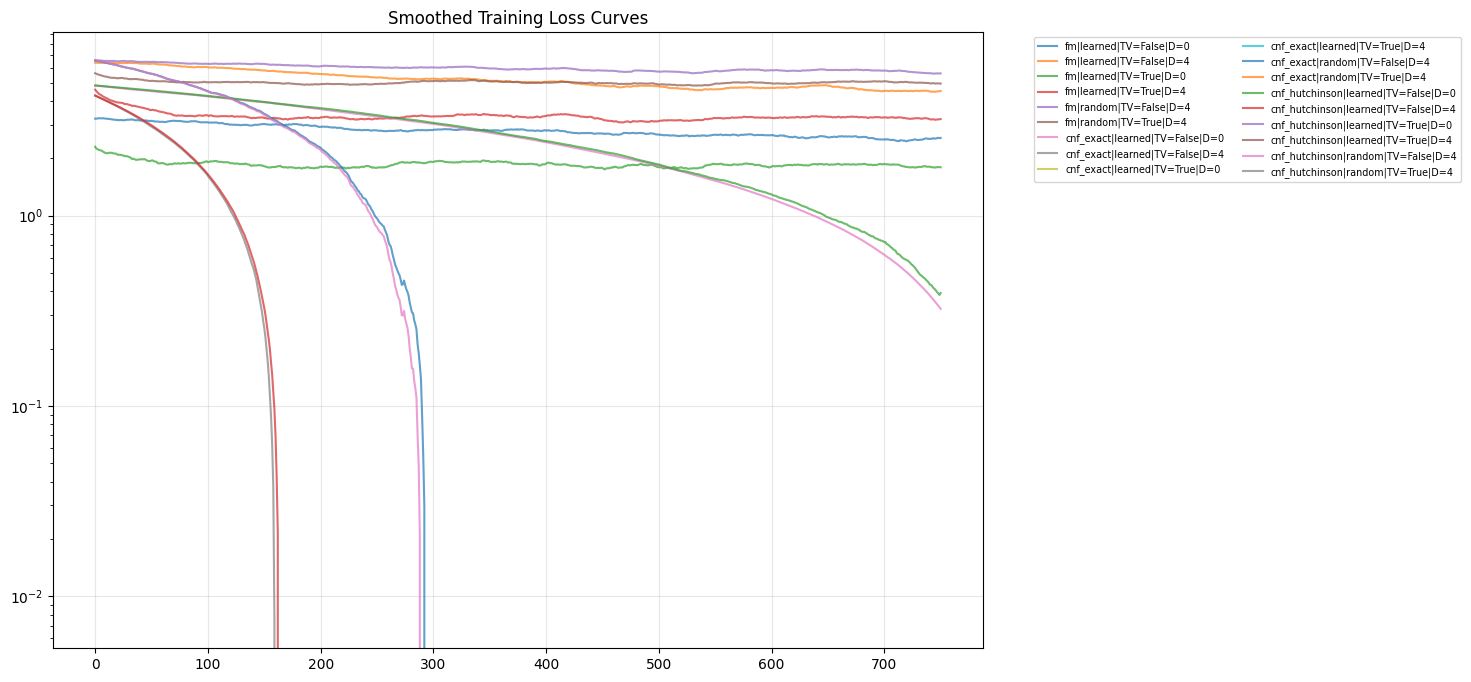

In [18]:
# Plot Loss Curves
plt.figure(figsize=(12, 8))
for res in results_log:
    # Simple smoothing
    y = np.convolve(res["loss"], np.ones(50) / 50, mode="valid")
    plt.plot(y, label=res["label"], alpha=0.7)

# Legend might be huge, so put outside
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="x-small", ncol=2)
plt.title("Smoothed Training Loss Curves")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()